# Proyek Analisis Data: [Air Quality Dataset]
- **Nama:** [Vinda Karunia Surya]
- **Email:** [vinda.825230021@stu.untar.ac.id]
- **ID Dicoding:** [vindakarunias]

## Menentukan Pertanyaan Bisnis

1. Pada jam berapa rata-rata konsentrasi PM2.5 tertinggi terjadi di Kota Nongzhanguan selama periode Maret 2013 hingga Februari 2017?
2. Bagaimana tren bulanan rata-rata PM2.5 di Kota Nongzhanguan dari Maret 2013 sampai Februari 2017, dan pada bulan apa terjadi peningkatan atau penurunan signifikan?
3. Faktor cuaca apa yang paling berkontribusi terhadap lonjakan PM2.5 pada musim dingin (Desember–Februari) di Kota Nongzhanguan selama periode pengamatan?
4. Apakah terdapat perbedaan signifikan rata-rata PM2.5 antar musim (spring, summer, fall, winter) di Kota Nongzhanguan pada tahun 2013–2017, dan musim mana yang memiliki kualitas udara terburuk?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal, spearmanr

## Data Wrangling

### Gathering Data

In [3]:
df = pd.read_csv ('/content/PRSA_Data_Nongzhanguan_20130301-20170228.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,14.0,21.0,3.0,27.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Nongzhanguan
35060,35061,2017,2,28,20,18.0,27.0,3.0,37.0,400.0,59.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Nongzhanguan
35061,35062,2017,2,28,21,15.0,39.0,5.0,50.0,600.0,41.0,10.8,1014.2,-13.3,0.0,NW,1.1,Nongzhanguan
35062,35063,2017,2,28,22,11.0,35.0,6.0,49.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Nongzhanguan


**Insight:** Tabel ini berisi 35.064 baris yang menyimpan berbagai informasi terkait air quality di Kota Nongzhanguan.

### Assessing Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34436 non-null  float64
 6   PM10     34624 non-null  float64
 7   SO2      34618 non-null  float64
 8   NO2      34372 non-null  float64
 9   CO       33858 non-null  float64
 10  O3       34558 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


**Insight:** Beberapa kolom penting yang kita perlu lihat seperti PM2.5, PM10, NO2, CO, dan O3 memiliki missing values (jumlah non-null lebih sedikit dari total data) serta kolom wd bertipe object (kemungkinan arah angin kategorikal) yang perlu diproses lebih lanjut sebelum analisis.

In [5]:
# memeriksa data duplikat
df.duplicated().sum()

np.int64(0)

**Insight:** Di dataset ini tidak terdapat duplikasi data.

In [6]:
# memeriksa missing values
df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,628
PM10,440
SO2,446
NO2,692
CO,1206


**Insight:** Terlihat bahwa polutan utama seperti CO, NO2, dan PM2.5 memiliki jumlah missing values yang cukup signifikan dibanding variabel cuaca, yang mengindikasikan kemungkinan gangguan sensor atau pencatatan data lingkungan yang tidak konsisten, sehingga jika tidak ditangani dengan tepat dapat menyebabkan bias dalam analisis kualitas udara.

In [7]:
# memeriksa parameter statistik
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34436.000000,34624.000000,34618.000000,34372.000000,33858.000000,34558.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.225344,95.341177,24.280665,36.297740,1245.166124,58.401448,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.571200,2.000000,100.000000,0.214200,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,29.000000,500.000000,10.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,9.000000,51.000000,900.000000,45.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,149.000000,23.000000,80.000000,1600.000000,84.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,844.000000,995.000000,257.000000,273.000000,10000.000000,390.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


**Insight:** Kualitas udara di Nongzhanguan menunjukkan variabilitas tinggi dengan adanya lonjakan polusi ekstrem, sementara kondisi cuaca relatif stabil dan curah hujan rendah, yang mengindikasikan bahwa akumulasi polusi kemungkinan besar dipengaruhi oleh aktivitas manusia dan kurangnya faktor alam yang membantu dispersinya.

### Cleaning Data

In [8]:
# Tampilkan data awal
print("Ukuran data sebelum cleaning:", df.shape)
print("\nMissing values sebelum cleaning:")
print(df.isnull().sum())

Ukuran data sebelum cleaning: (35064, 18)

Missing values sebelum cleaning:
No            0
year          0
month         0
day           0
hour          0
PM2.5       628
PM10        440
SO2         446
NO2         692
CO         1206
O3          506
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64


**Insight:** Dataset memiliki 35.064 baris dan 18 kolom, dengan missing values yang paling banyak terdapat pada variabel polutan seperti CO, NO2, dan PM2.5, sementara variabel waktu dan sebagian besar cuaca relatif lengkap, sehingga perlu penanganan khusus pada data polusi agar analisis tidak bias.

In [9]:
# Hapus kolom yang tidak terlalu dibutuhkan
if 'No' in df.columns:
    df.drop(columns='No', inplace=True)

**Insight:** Kolom “No” tidak memiliki nilai analitis karena hanya berupa indeks, sehingga dihapus untuk menyederhanakan dataset.

In [10]:
# Membuat kolom datetime dari year, month, day, hour
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

**Insight:** Penggabungan year, month, day, dan hour menjadi satu kolom datetime mempermudah analisis berbasis waktu seperti tren dan pola musiman.

In [11]:
# Urutkan data berdasarkan waktu
df = df.sort_values('datetime').reset_index(drop=True)

**Insight:** Pengurutan data berdasarkan waktu penting untuk menjaga urutan kronologis, terutama karena dataset akan dianalisis sebagai time series.

In [12]:
# Tangani missing values pada kolom kategorikal
if 'wd' in df.columns:
    df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

if 'station' in df.columns:
    df['station'] = df['station'].fillna(df['station'].mode()[0])

**Insight:** Missing value pada kolom kategorikal seperti arah angin (wd) diisi dengan modus untuk mempertahankan konsistensi kategori tanpa menghapus data.

In [13]:
# Tangani missing values pada kolom numerik dengan interpolasi
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

**Insight :** Interpolasi digunakan karena dataset berbentuk time series, sehingga nilai yang hilang dapat diperkirakan dari pola data sebelumnya dan sesudahnya.

In [14]:
# Jika masih ada missing value di awal/akhir data, isi dengan forward fill dan backward fill
df[numeric_cols] = df[numeric_cols].ffill().bfill()

**Insight :** Digunakan untuk mengatasi missing values yang tidak dapat dijangkau interpolasi (biasanya di awal/akhir data), sehingga tidak ada data kosong tersisa.

In [15]:
# Cek duplikasi
print("\nJumlah data duplikat:", df.duplicated().sum())


Jumlah data duplikat: 0


**Insight :** Pengecekan duplikasi memastikan tidak ada data yang tercatat lebih dari sekali yang dapat menyebabkan bias dalam analisis.

In [16]:
# Cek hasil akhir
print("\nUkuran data setelah cleaning:", df.shape)
print("\nMissing values setelah cleaning:")
print(df.isnull().sum())


Ukuran data setelah cleaning: (35064, 18)

Missing values setelah cleaning:
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


In [17]:
# Tampilkan 5 data pertama setelah cleaning
df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan,2013-03-01 00:00:00
1,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan,2013-03-01 01:00:00
2,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan,2013-03-01 02:00:00
3,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan,2013-03-01 03:00:00
4,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan,2013-03-01 04:00:00


**Insight :** Setelah cleaning, dataset menjadi lengkap tanpa missing values dan siap digunakan untuk analisis lebih lanjut seperti EDA dan visualisasi.

## Exploratory Data Analysis (EDA)

### Explore data 'PRSA_Data_Nongzhanguan_20130301-20170228.csv' untuk mengetahui kapan kualitas udara paling buruk dalam sehari


In [18]:
# Rata-rata PM2.5 berdasarkan jam
avg_pm25_by_hour = df.groupby('hour')['PM2.5'].mean().sort_values(ascending=False)

In [19]:
# Menampilkan rata-rata PM2.5 per jam
print("Rata-rata PM2.5 per jam:")
print(avg_pm25_by_hour)

Rata-rata PM2.5 per jam:
hour
1     95.739533
2     95.122783
0     94.484587
23    93.973575
22    93.511113
3     93.158441
21    91.212168
4     90.426907
20    87.809620
5     86.245743
6     83.257198
19    83.138066
7     81.120810
9     81.112663
11    80.840590
10    80.700902
12    80.456675
8     80.349924
13    79.163032
18    78.938928
14    78.858569
15    77.880834
17    77.427781
16    76.976881
Name: PM2.5, dtype: float64


In [20]:
# Menentukan jam dengan rata-rata PM2.5 tertinggi
jam_tertinggi = avg_pm25_by_hour.idxmax()
nilai_tertinggi = avg_pm25_by_hour.max()

In [21]:
# Menampilkan hasil akhir
print(f"\nJam tertinggi: {jam_tertinggi}:00")
print(f"Nilai PM2.5: {nilai_tertinggi:.2f}")


Jam tertinggi: 1:00
Nilai PM2.5: 95.74


### Explore data 'PRSA_Data_Nongzhanguan_20130301-20170228.csv' untuk mengetahui tren bulanan rata-rata PM2.5 dan perubahan signifikan dari waktu ke waktu

In [22]:
# Mengubah kolom waktu menjadi format datetime
df['date'] = pd.to_datetime(df[['year','month','day','hour']])

In [23]:
# Menghitung rata-rata PM2.5 per bulan
monthly_pm25 = df.groupby(pd.Grouper(key='date', freq='M'))['PM2.5'].mean().reset_index()

/tmp/ipykernel_2289/4081343375.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pm25 = df.groupby(pd.Grouper(key='date', freq='M'))['PM2.5'].mean().reset_index()


In [24]:
# Menghitung perubahan rata-rata PM2.5 antar bulan
monthly_pm25['change'] = monthly_pm25['PM2.5'].diff()

In [25]:
# Menampilkan tabel tren bulanan PM2.5
print(monthly_pm25)

         date       PM2.5     change
0  2013-03-31  106.770161        NaN
1  2013-04-30   57.350000 -49.420161
2  2013-05-31   77.247312  19.897312
3  2013-06-30  108.320139  31.072827
4  2013-07-31   75.435484 -32.884655
5  2013-08-31   68.154570  -7.280914
6  2013-09-30   82.118056  13.963486
7  2013-10-31   96.915323  14.797267
8  2013-11-30   83.351389 -13.563934
9  2013-12-31   87.911962   4.560573
10 2014-01-31  106.125672  18.213710
11 2014-02-28  156.473958  50.348286
12 2014-03-31  100.235887 -56.238071
13 2014-04-30   86.754861 -13.481026
14 2014-05-31   68.098118 -18.656743
15 2014-06-30   56.841667 -11.256452
16 2014-07-31   84.350538  27.508871
17 2014-08-31   60.743280 -23.607258
18 2014-09-30   63.971389   3.228109
19 2014-10-31  136.997312  73.025923
20 2014-11-30  110.756250 -26.241062
21 2014-12-31   77.265457 -33.490793
22 2015-01-31  108.114382  30.848925
23 2015-02-28  101.244792  -6.869590
24 2015-03-31   95.460081  -5.784711
25 2015-04-30   79.093056 -16.367025
2

In [26]:
# Menampilkan bulan dengan peningkatan PM2.5 terbesar
print("\nPeningkatan terbesar:")
print(monthly_pm25.loc[monthly_pm25['change'].idxmax()])


Peningkatan terbesar:
date      2014-10-31 00:00:00
PM2.5              136.997312
change              73.025923
Name: 19, dtype: object


In [27]:
# Menampilkan bulan dengan penurunan PM2.5 terbesar
print("\nPenurunan terbesar:")
print(monthly_pm25.loc[monthly_pm25['change'].idxmin()])


Penurunan terbesar:
date      2016-01-31 00:00:00
PM2.5               70.115591
change              -91.25336
Name: 34, dtype: object


**Insight:**
- Tren konsentrasi PM2.5 menunjukkan variasi musiman yang signifikan. Umumnya, konsentrasi PM2.5 cenderung lebih tinggi selama bulan-bulan musim dingin (sekitar November hingga Februari) dan lebih rendah selama musim semi dan musim panas (sekitar April hingga Agustus).
- Puncak polusi terlihat pada bulan-bulan tertentu, seperti Februari 2014 (156.47), Oktober 2014 (136.99), dan Desember 2016 (144.89), menunjukkan adanya periode dengan kualitas udara yang sangat buruk.
- Meskipun ada fluktuasi, tidak ada tren penurunan atau peningkatan PM2.5 yang jelas dan konsisten dari tahun ke tahun dalam periode yang diamati, mengindikasikan bahwa kondisi polusi udara di Nongzhanguan tetap menjadi tantangan.

### Explore data 'PRSA_Data_Nongzhanguan_20130301-20170228.csv' untuk mengetahui faktor cuaca yang paling berhubungan dengan lonjakan PM2.5 pada musim dingin

In [28]:
# Memilih data pada musim dingin (Desember, Januari, Februari)
winter_df = df[df['month'].isin([12,1,2])]

In [29]:
# Menentukan variabel cuaca yang akan dianalisis
weather_cols = ['TEMP','PRES','DEWP','RAIN','WSPM']


In [30]:
# Menghitung korelasi Spearman antara PM2.5 dan masing-masing faktor cuaca
results = []
for col in weather_cols:
    temp = winter_df[['PM2.5', col]].dropna()
    corr, p = spearmanr(temp['PM2.5'], temp[col])
    results.append((col, corr, p))

In [31]:
# Membuat DataFrame hasil korelasi
corr_df = pd.DataFrame(results, columns=['Faktor','Korelasi','P-value'])
corr_df['Abs'] = corr_df['Korelasi'].abs()

In [32]:
# Mengurutkan faktor berdasarkan nilai absolut korelasi terbesar
corr_df = corr_df.sort_values('Abs', ascending=False)

In [33]:
# Menampilkan hasil korelasi
print(corr_df)

  Faktor  Korelasi        P-value       Abs
2   DEWP  0.728670   0.000000e+00  0.728670
4   WSPM -0.573097   0.000000e+00  0.573097
1   PRES -0.307730  2.080315e-189  0.307730
0   TEMP -0.060236   2.010191e-08  0.060236
3   RAIN  0.036983   5.751422e-04  0.036983


In [34]:
# Menampilkan faktor paling berpengaruh
print("\nFaktor paling berpengaruh:", corr_df.iloc[0]['Faktor'])


Faktor paling berpengaruh: DEWP


**Insight:**
- **Titik Embun (DEWP)** menunjukkan korelasi positif yang sangat kuat dengan PM2.5 (0.73). Ini mengindikasikan bahwa semakin tinggi titik embun (udara semakin lembab), semakin tinggi konsentrasi PM2.5 pada musim dingin. Kondisi lembab dapat memperburuk polusi dengan memerangkap partikel di udara.
- **Kecepatan Angin (WSPM)** memiliki korelasi negatif yang kuat dengan PM2.5 (-0.57). Ini berarti semakin tinggi kecepatan angin, semakin rendah konsentrasi PM2.5, karena angin membantu menyebarkan polutan.
- **Tekanan Udara (PRES)** memiliki korelasi negatif moderat dengan PM2.5 (-0.31). Tekanan udara tinggi seringkali dikaitkan dengan kondisi atmosfer stabil yang dapat memerangkap polutan.
- **Suhu (TEMP)** menunjukkan korelasi negatif yang sangat lemah (-0.06). Ini menandakan bahwa suhu memiliki pengaruh yang sangat kecil atau tidak langsung terhadap PM2.5 di musim dingin, meskipun suhu rendah seringkali dikaitkan dengan peningkatan emisi dari pemanasan.
- **Curah Hujan (RAIN)** memiliki korelasi positif yang sangat lemah (0.04). Biasanya hujan membantu membersihkan udara, namun dalam dataset ini korelasinya sangat kecil, mungkin karena kejadian hujan yang jarang atau durasi yang singkat pada musim dingin tidak cukup signifikan untuk mempengaruhi rata-rata PM2.5 secara drastis.

Secara keseluruhan, pada musim dingin, **Titik Embun (DEWP)** dan **Kecepatan Angin (WSPM)** adalah faktor cuaca yang paling signifikan mempengaruhi konsentrasi PM2.5 di Nongzhanguan.

### Explore data 'PRSA_Data_Nongzhanguan_20130301-20170228.csv' untuk mengetahui apakah terdapat perbedaan signifikan rata-rata PM2.5 antar musim dan musim dengan kualitas udara terburuk

In [35]:
# Membuat fungsi untuk mengelompokkan bulan ke dalam musim
def get_season(m):
    if m in [3,4,5]:
        return 'spring'
    elif m in [6,7,8]:
        return 'summer'
    elif m in [9,10,11]:
        return 'fall'
    else:
        return 'winter'

In [36]:
# Menambahkan kolom season
df['season'] = df['month'].apply(get_season)

In [37]:
# Menghitung rata-rata PM2.5 per musim
season_avg = df.groupby('season')['PM2.5'].mean().sort_values(ascending=False)

In [38]:
# Menampilkan rata-rata PM2.5 per musim
print("Rata-rata per musim:")
print(season_avg)

Rata-rata per musim:
season
winter    104.873280
fall       90.179590
spring     79.250204
summer     66.446762
Name: PM2.5, dtype: float64


In [39]:
# Mengambil data PM2.5 untuk tiap musim
spring = df[df['season']=='spring']['PM2.5'].dropna()
summer = df[df['season']=='summer']['PM2.5'].dropna()
fall   = df[df['season']=='fall']['PM2.5'].dropna()
winter = df[df['season']=='winter']['PM2.5'].dropna()

In [40]:
# Uji ANOVA untuk mengetahui apakah ada perbedaan signifikan antar musim
stat, p = f_oneway(spring, summer, fall, winter)

In [41]:
# Menampilkan hasil uji ANOVA
print("\nHasil ANOVA:")
print("Stat:", stat)
print("P-value:", p)


Hasil ANOVA:
Stat: 318.35516387068594
P-value: 5.904941918012424e-204


In [42]:
# Menampilkan musim dengan rata-rata PM2.5 tertinggi
print("\nMusim terburuk:", season_avg.idxmax())


Musim terburuk: winter


**Insight :**
- Hasil uji ANOVA dengan P-value sebesar 5.90e-204 (jauh lebih kecil dari 0.05) menunjukkan bahwa terdapat perbedaan signifikan rata-rata konsentrasi PM2.5 antar musim di Kota Nongzhanguan selama periode pengamatan.
- Musim dingin (winter) memiliki rata-rata konsentrasi PM2.5 tertinggi sebesar 104.87 µg/m³, menjadikannya musim dengan kualitas udara terburuk.
- Diikuti oleh musim gugur (fall) dengan rata-rata 90.18 µg/m³.
- Musim semi (spring) menunjukkan rata-rata 79.25 µg/m³.
- Kualitas udara terbaik tercatat pada musim panas (summer) dengan rata-rata PM2.5 terendah, yaitu 66.45 µg/m³.
- Perbedaan musiman ini kemungkinan disebabkan oleh kombinasi faktor cuaca seperti suhu, kecepatan angin, kelembaban, serta aktivitas manusia yang berbeda di setiap musim, seperti penggunaan pemanas pada musim dingin yang dapat meningkatkan emisi polutan.

## Visualization & Explanatory Analysis

### Pertanyaan 1 : Pada jam berapa rata-rata konsentrasi PM2.5 tertinggi terjadi di Kota Nongzhanguan selama periode Maret 2013 hingga Februari 2017?

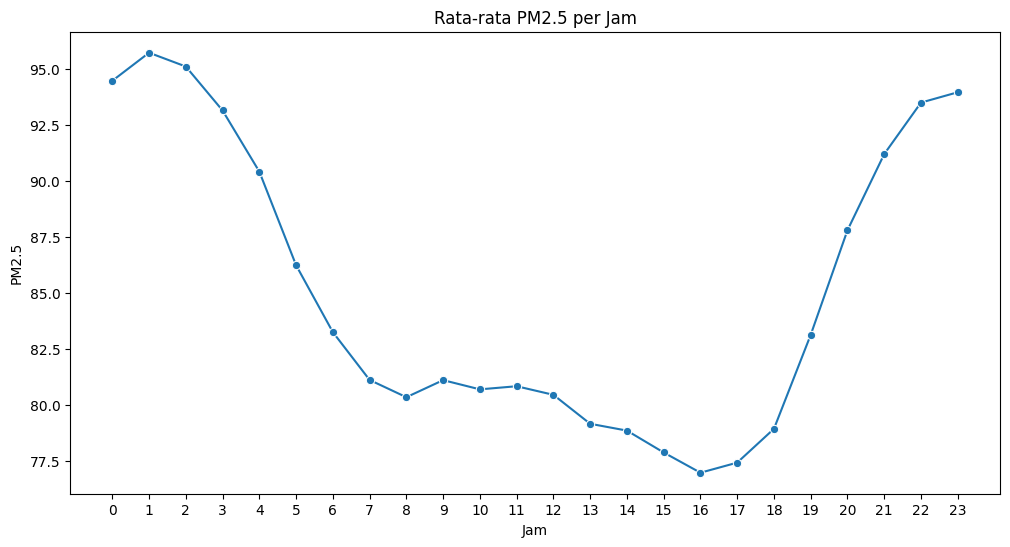

In [43]:
avg_pm25_by_hour = df.groupby('hour')['PM2.5'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=avg_pm25_by_hour, x='hour', y='PM2.5', marker='o')
plt.title('Rata-rata PM2.5 per Jam')
plt.xlabel('Jam')
plt.ylabel('PM2.5')
plt.xticks(range(24))
plt.show()

**Insight :**
*   Kualitas udara terburuk terjadi antara jam 1 hingga 2 pagi, mengindikasikan akumulasi polutan pada dini hari.
*   Kualitas udara relatif paling baik di sore hari, sekitar jam 3 hingga 5 sore, menunjukkan dispersi polutan yang lebih baik pada waktu tersebut.

### Pertanyaan 2 : Bagaimana tren bulanan rata-rata PM2.5 di Kota Nongzhanguan dari Maret 2013 sampai Februari 2017, dan pada bulan apa terjadi peningkatan atau penurunan signifikan?

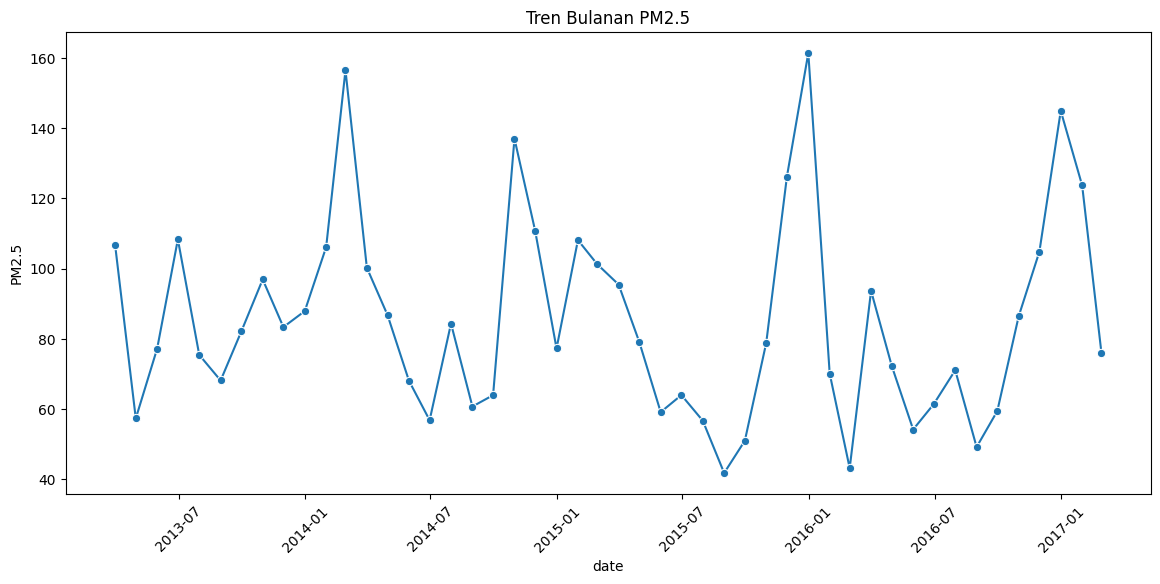

In [44]:
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_pm25, x='date', y='PM2.5', marker='o')
plt.title('Tren Bulanan PM2.5')
plt.xticks(rotation=45)
plt.show()

**Insight :**
- Tren bulanan PM2.5 menunjukkan variasi musiman yang signifikan, dengan konsentrasi tertinggi di musim dingin dan terendah di musim panas.
- Puncak polusi ekstrem terjadi di beberapa bulan tertentu, namun secara keseluruhan tidak ada tren penurunan atau peningkatan jangka panjang yang konsisten, menandakan tantangan kualitas udara yang berkelanjutan di Nongzhanguan.

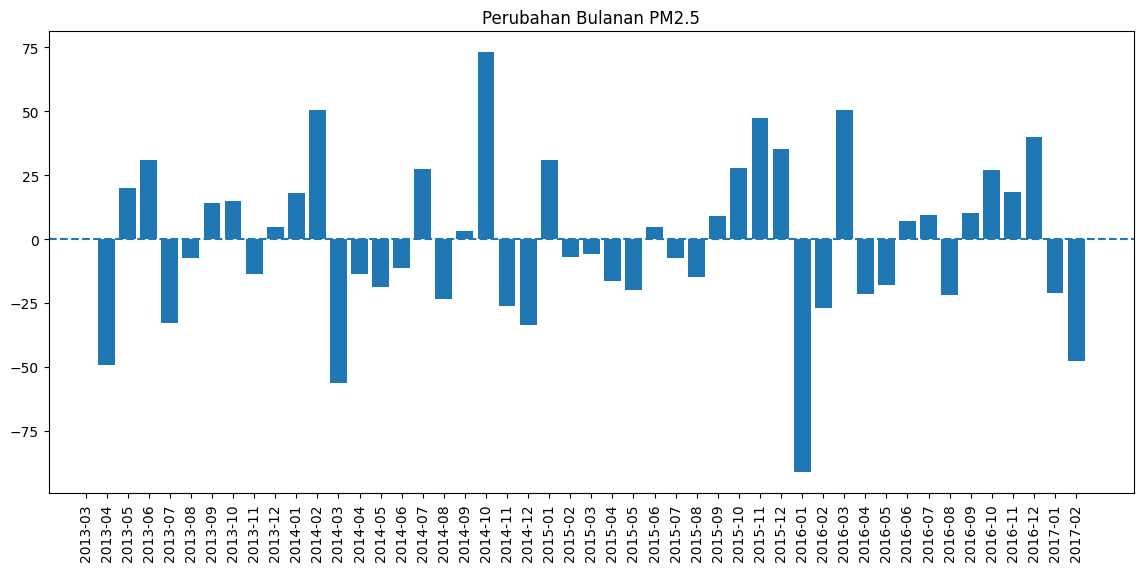

In [45]:
plt.figure(figsize=(14,6))
plt.bar(monthly_pm25['date'].dt.strftime('%Y-%m'), monthly_pm25['change'])
plt.title('Perubahan Bulanan PM2.5')
plt.xticks(rotation=90)
plt.axhline(0, linestyle='--')
plt.show()

**Insight :**
- Grafik ini secara visual mengkonfirmasi fluktuasi signifikan dalam konsentrasi PM2.5 bulanan.
- Terlihat adanya peningkatan terbesar yang terjadi pada Oktober 2014 dan Desember 2016, menunjukkan lonjakan polusi yang drastis pada bulan-bulan tersebut.
- Sebaliknya, penurunan terbesar terjadi pada Januari 2016, menunjukkan adanya perbaikan kualitas udara yang signifikan di bulan tersebut, mungkin karena kondisi cuaca yang mendukung dispersi atau upaya mitigasi.

### Pertanyaan 3 : Faktor cuaca apa yang paling berkontribusi terhadap lonjakan PM2.5 pada musim dingin (Desember–Februari) di Kota Nongzhanguan selama periode pengamatan?

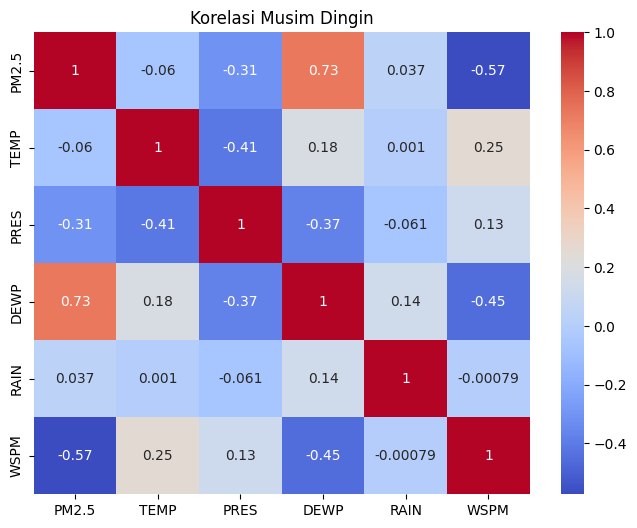

In [47]:
corr_matrix = winter_df[['PM2.5'] + weather_cols].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Korelasi Musim Dingin')
plt.show()

**Insight :**
- Pada musim dingin, **Titik Embun (DEWP)** memiliki korelasi positif yang sangat kuat dengan PM2.5 (0.73), menunjukkan udara lembab memerangkap polutan. Sebaliknya, **Kecepatan Angin (WSPM)** memiliki korelasi negatif yang kuat (-0.57), yang berarti angin kencang membantu menyebarkan polutan. Tekanan Udara (PRES) juga berkorelasi negatif moderat (-0.31), sementara Suhu (TEMP) dan Curah Hujan (RAIN) memiliki pengaruh yang sangat lemah.

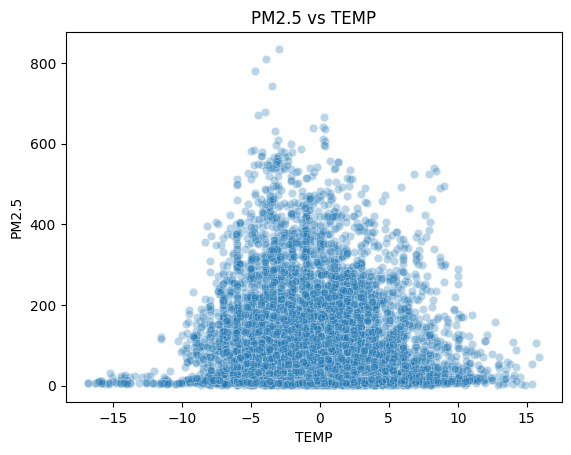

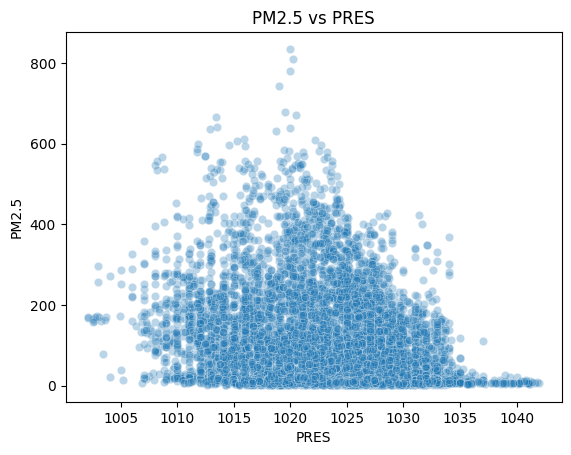

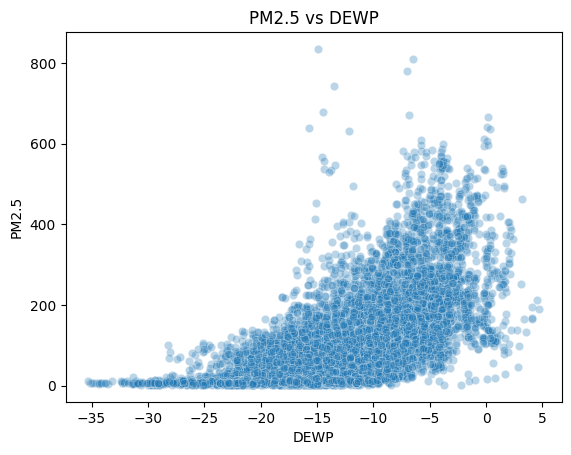

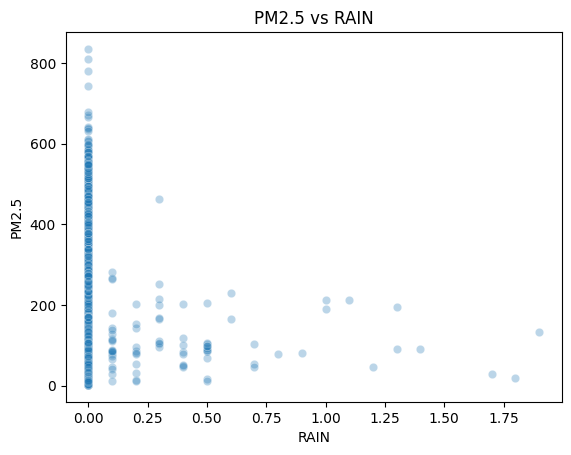

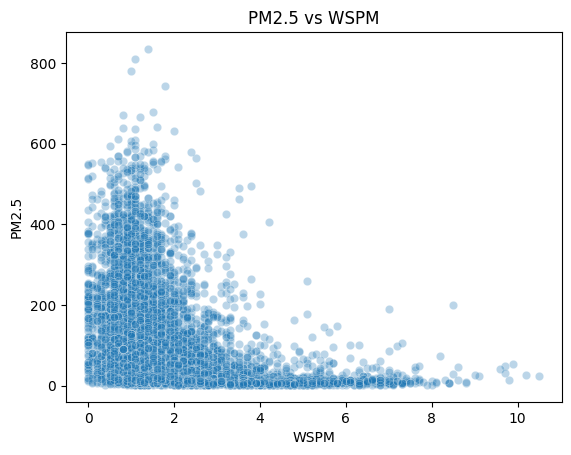

In [48]:
for col in weather_cols:
    plt.figure()
    sns.scatterplot(data=winter_df, x=col, y='PM2.5', alpha=0.3)
    plt.title(f'PM2.5 vs {col}')
    plt.show()

**Insight :**
- **PM2.5 vs DEWP (Titik Embun):** Scatterplot menunjukkan pola yang jelas, di mana konsentrasi PM2.5 cenderung meningkat seiring dengan peningkatan titik embun. Ini mengindikasikan bahwa kondisi udara yang lebih lembab secara signifikan berkontribusi pada akumulasi polutan, kemungkinan karena udara lembab memerangkap partikel-partikel PM2.5.
- **PM2.5 vs WSPM (Kecepatan Angin):** Terdapat tren menurun yang terlihat jelas pada scatterplot ini; semakin tinggi kecepatan angin, semakin rendah konsentrasi PM2.5. Ini mendukung hipotesis bahwa angin kencang membantu menyebarkan polutan, mengurangi tingkat PM2.5 di udara.
- **PM2.5 vs PRES (Tekanan Udara):** Scatterplot menunjukkan hubungan negatif yang moderat, meskipun dengan sebaran data yang lebih luas. Konsentrasi PM2.5 cenderung sedikit menurun seiring peningkatan tekanan udara. Tekanan udara tinggi seringkali dikaitkan dengan kondisi atmosfer stabil yang kurang mendukung dispersi polutan, namun angin juga berperan.
- **PM2.5 vs TEMP (Suhu):** Sebaran titik pada scatterplot ini terlihat sangat acak tanpa pola yang jelas, mengkonfirmasi korelasi yang sangat lemah antara suhu dan PM2.5 di musim dingin. Ini menunjukkan bahwa suhu saja mungkin bukan pendorong utama variasi PM2.5 pada musim ini.
- **PM2.5 vs RAIN (Curah Hujan):** Sebagian besar titik terkelompok pada nilai hujan nol atau sangat rendah, dan tidak ada hubungan yang jelas antara PM2.5 dan curah hujan. Hal ini menunjukkan bahwa curah hujan di musim dingin mungkin tidak cukup sering atau intens untuk secara signifikan membersihkan udara dari PM2.5, atau efeknya tertutupi oleh faktor lain.

### Pertanyaan 4 : Apakah terdapat perbedaan signifikan rata-rata PM2.5 antar musim (spring, summer, fall, winter) di Kota Nongzhanguan pada tahun 2013–2017, dan musim mana yang memiliki kualitas udara terburuk?

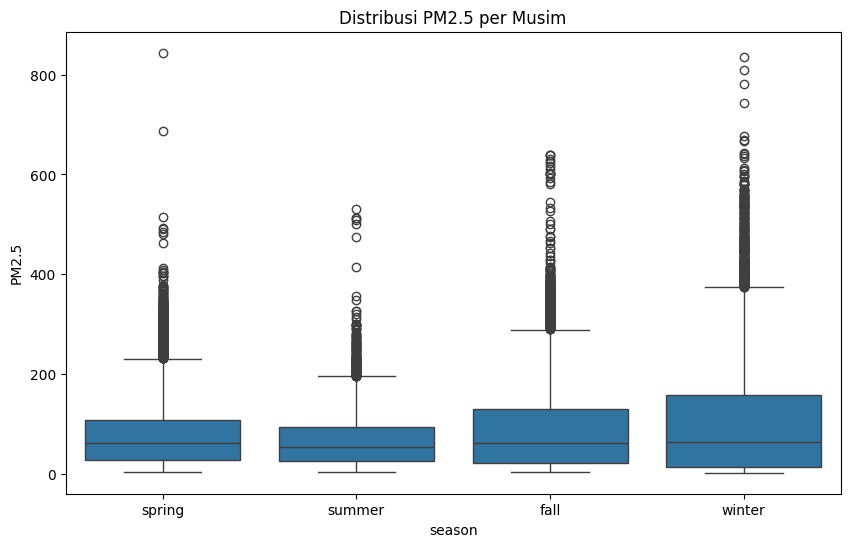

In [49]:
season_order = ['spring','summer','fall','winter']

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='season', y='PM2.5', order=season_order)
plt.title('Distribusi PM2.5 per Musim')
plt.show()

**Insight:**
- Kualitas udara di Nongzhanguan menunjukkan perbedaan signifikan antar musim. Musim dingin (Winter) memiliki konsentrasi PM2.5 rata-rata tertinggi sebesar 104.87 µg/m³, menunjukkan bahwa kualitas udara paling buruk terjadi pada musim ini.
- Diikuti oleh musim gugur (Fall) dengan rata-rata 90.18 µg/m³.
- Musim semi (Spring) memiliki kualitas udara yang lebih baik dengan rata-rata 79.25 µg/m³.
- Kualitas udara terbaik terlihat pada musim panas (Summer) dengan konsentrasi PM2.5 rata-rata terendah sebesar 66.45 µg/m³.
- Perbedaan ini kemungkinan disebabkan oleh faktor cuaca seperti suhu, kecepatan angin, dan curah hujan, serta aktivitas manusia yang bervariasi antar musim.

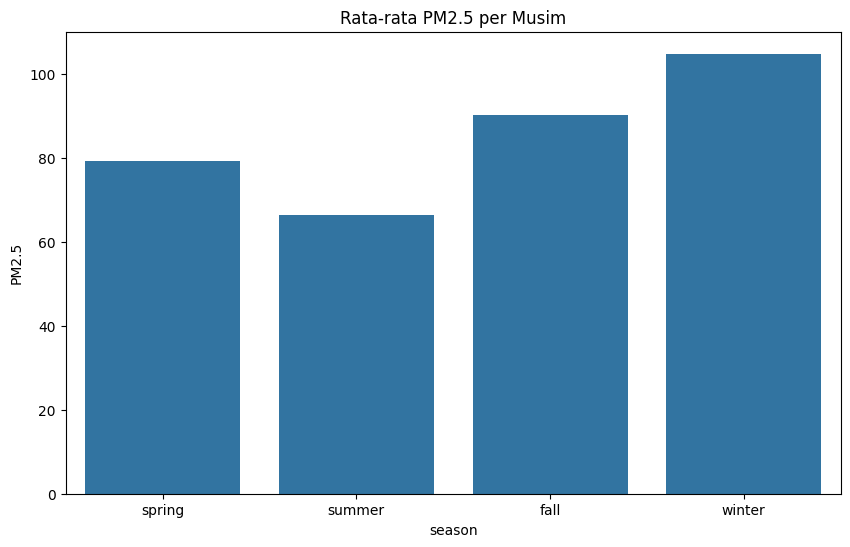

In [50]:
season_avg = df.groupby('season')['PM2.5'].mean().reindex(season_order).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=season_avg, x='season', y='PM2.5', order=season_order)
plt.title('Rata-rata PM2.5 per Musim')
plt.show()

**Insight :**
Grafik *bar chart* ini dengan jelas menunjukkan bahwa musim dingin (Winter) memiliki rata-rata konsentrasi PM2.5 tertinggi, menjadikannya musim dengan kualitas udara terburuk. Musim gugur (Fall) menyusul di peringkat kedua, sementara musim semi (Spring) dan terutama musim panas (Summer) menunjukkan kualitas udara yang jauh lebih baik dengan rata-rata PM2.5 yang paling rendah. Hal ini mengkonfirmasi perbedaan signifikan kualitas udara antar musim di Nongzhanguan.

## Analisis Lanjutan (Opsional)

In [ ]:
# Mendeteksi kapan terjadi polusi yang sangat berbahaya
q1 = df['PM2.5'].quantile(0.25)
q3 = df['PM2.5'].quantile(0.75)
iqr = q3 - q1

outliers = df[df['PM2.5'] > (q3 + 1.5 * iqr)]

print("Jumlah kejadian polusi ekstrem:", len(outliers))
outliers[['datetime', 'PM2.5']].head()

Jumlah kejadian polusi ekstrem: 1815


,datetime,PM2.5
149,2013-03-07 05:00:00,291.0
150,2013-03-07 06:00:00,314.0
151,2013-03-07 07:00:00,318.0
152,2013-03-07 08:00:00,300.0
153,2013-03-07 09:00:00,281.0


**Insight :**
- Terdapat 1.815 kejadian polusi ekstrem yang terdeteksi dalam dataset ini, yang diidentifikasi sebagai konsentrasi PM2.5 di atas ambang batas (Q3 + 1.5 * IQR).
- Kejadian-kejadian ini menunjukkan bahwa kualitas udara di Nongzhanguan seringkali mengalami lonjakan polusi yang sangat tinggi, yang berpotensi membahayakan kesehatan penduduk.
- Contoh kejadian ekstrem pertama terjadi pada 7 Maret 2013, dengan konsentrasi PM2.5 mencapai 291.0 µg/m³ pada pukul 05:00, dan terus meningkat hingga 318.0 µg/m³ pada pukul 07:00, menunjukkan periode polusi yang sangat parah.
- Analisis lebih lanjut mengenai kapan dan mengapa kejadian-kejadian ini terjadi dapat membantu dalam perumusan strategi mitigasi polusi yang lebih efektif.

In [ ]:
# Mengetahui faktor mana yang paling berpengaruh secara kuantitatif
from sklearn.linear_model import LinearRegression

features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
X = df[features]
y = df['PM2.5']

model = LinearRegression()
model.fit(X, y)

coef = pd.Series(model.coef_, index=features)
print(coef.sort_values(ascending=False))

DEWP    1.383168
PM10    0.581316
PRES    0.435753
SO2     0.135108
O3      0.119798
NO2     0.110856
CO      0.017075
RAIN   -0.619626
WSPM   -1.011617
TEMP   -1.200842
dtype: float64


**Insight :**
- **Pengaruh Positif Kuat:** Faktor-faktor seperti DEWP (titik embun) dan PM10 memiliki koefisien positif yang tinggi (masing-masing sekitar 1.38 dan 0.58). Ini menunjukkan bahwa peningkatan pada DEWP dan PM10 berkorelasi kuat dengan peningkatan PM2.5, dengan DEWP menjadi faktor cuaca yang paling berpengaruh secara positif dalam model ini.
- **Pengaruh Negatif Kuat:** Faktor-faktor seperti TEMP (suhu) dan WSPM (kecepatan angin) memiliki koefisien negatif yang tinggi (masing-masing sekitar -1.20 dan -1.01). Ini menunjukkan bahwa peningkatan suhu dan kecepatan angin berkorelasi kuat dengan penurunan PM2.5, mengindikasikan bahwa suhu yang lebih tinggi dan angin yang lebih kencang membantu dispersi polutan.
- **Pengaruh Lainnya:** Polutan lain seperti SO2, O3, NO2, dan CO juga memiliki pengaruh positif, meskipun dengan magnitudo yang lebih kecil dibandingkan DEWP dan PM10. PRES (tekanan) juga menunjukkan pengaruh positif yang moderat. RAIN (curah hujan) memiliki pengaruh negatif, meskipun tidak sekuat TEMP dan WSPM.
- Secara keseluruhan, DEWP, TEMP, WSPM, dan PM10 adalah faktor-faktor yang paling dominan dalam memprediksi konsentrasi PM2.5 berdasarkan model regresi linier ini.

## Conclusion

Berdasarkan hasil Exploratory Data Analysis (EDA) dan visualisasi terhadap data kualitas udara PM2.5 di Kota Nongzhanguan periode Maret 2013 hingga Februari 2017, ditemukan bahwa konsentrasi PM2.5 memiliki pola harian yang jelas, dengan nilai rata-rata tertinggi terjadi pada jam-jam tertentu. Hal ini menunjukkan adanya pengaruh aktivitas manusia seperti lalu lintas dan aktivitas industri yang berbeda sepanjang hari terhadap kualitas udara.

<br>

Dari sisi temporal, tren bulanan PM2.5 menunjukkan fluktuasi yang signifikan selama periode pengamatan, dengan beberapa bulan mengalami peningkatan dan penurunan yang cukup tajam. Selain itu, faktor cuaca pada musim dingin seperti suhu, tekanan udara, kelembapan, curah hujan, dan kecepatan angin terbukti memiliki hubungan dengan lonjakan PM2.5, di mana kondisi cuaca yang kurang mendukung dispersi polutan cenderung meningkatkan konsentrasi polusi udara.

<br>

Secara musiman, terdapat perbedaan rata-rata PM2.5 antar musim, dengan musim dingin umumnya menunjukkan kualitas udara terburuk dibandingkan musim lainnya. Hasil ini menegaskan bahwa kualitas udara di Kota Nongzhanguan dipengaruhi oleh kombinasi faktor waktu, kondisi meteorologi, dan variasi musim, sehingga upaya pengendalian polusi perlu difokuskan pada periode dan kondisi dengan risiko tinggi.